# Singular drift: DTB and direct Euler

Run all cells from the repository root or `DTB_Game_Ver2`, or open in Colab.
Set `RUN_DTB` and `RUN_EULER` in the first code cell. Both default to `True`;
set `RUN_DTB=False` for Euler alone. Rerun from the first cell after changing
controls. Dependencies: PyTorch, NumPy, and Matplotlib. Shared functions are imported
from the repository, following the [Cournot DTB example](https://github.com/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/DTB_Game_Ver2/cournot_3d_nonpotential_stochastic_mlp_dtb.ipynb).

For $r=x_1-x_2$, the dynamics are
$$\dot x=b(x)=\left(-\frac{2}{r},-\frac{1}{r}\right).$$

The diagonal $x_1=x_2$ is singular. Initially, sample $c\sim U[-1,1]$ and
$r\sim U[1,2]$, then set $z=(c+2r,c+r)$. The first singular encounter can occur near $t=0.5$. A requested horizon
may be later; each numerical method stops independently when a proposed
particle approaches the diagonal, and unavailable snapshots are labeled.

In [1]:
# Experiment switches: Euler can run without constructing or running DTB.
RUN_DTB = True
RUN_EULER = True

from pathlib import Path
import math
import subprocess
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import torch

# Euler-only runs need no shared neural modules or repository download.
if RUN_DTB:
    # Reuse the same core functions as the Cournot notebook.
    MODULE_FILES = ('dtb.py', 'run_game_dtb.py', 'network.py', 'utility.py')
    candidates = (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2',
                  Path.cwd() / 'dtb-colab-experiments-game-codex' / 'DTB_Game_Ver2')
    EXPERIMENT_DIR = next((p for p in candidates
                           if all((p / name).is_file() for name in MODULE_FILES)), None)
    if EXPERIMENT_DIR is None:
        if not Path('/content').is_dir():
            raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2.')
        repo = Path('/content/dtb-colab-experiments')
        if not repo.exists():
            subprocess.run(['git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
                            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo)], check=True)
        EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'
    if not all((EXPERIMENT_DIR / name).is_file() for name in MODULE_FILES):
        raise FileNotFoundError('The checkout does not contain the required shared modules.')
    sys.path.insert(0, str(EXPERIMENT_DIR.resolve()))
    from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices
    from dtb import flat_params, jform_solve
    from network import count_trainable
    from utility import plot_tangent_diagnostics

DEVICE = torch.device('cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))

SEED = 0
N = 1024                     # Particles used for the tangent projection.
N_SNAPSHOT = 2048            # Independent particles used only for the snapshots.
WIDTH = 16
DEPTH = 2
BASIS_SIZE = 32
SVD_RTOL = 1e-3              # Same truncation convention as the Cournot notebook.
SVD_METHOD = 'svd_gpu'       # Uses the current device; also works on CPU float64.
JACOBIAN_CHUNK = 256
H = 1e-3
T = 0.6
STOP_GAP = 0.02

# Clear old results when restarting after changing switches or controls.
dtb_result, euler_result = None, None


In [2]:
def dynamic_drift(x):
    r = x[..., 0] - x[..., 1]
    if not torch.isfinite(x).all() or torch.any(r == 0):
        raise FloatingPointError('Drift is undefined at a nonfinite state or x1=x2.')
    return torch.stack((-2 / r, -1 / r), dim=-1)


def sample_initial(n, seed):
    generator = torch.Generator().manual_seed(seed)
    u = torch.rand(n, 2, generator=generator, dtype=DTYPE).to(DEVICE)
    c, r = 2*u[:, 0] - 1, 1 + u[:, 1]
    return torch.stack((c + 2*r, c + r), dim=-1)

def experiment_grid(h, t_final):
    if not all(math.isfinite(v) and v > 0 for v in (h, t_final)):
        raise ValueError('h and t_final must be finite and positive.')
    steps = math.ceil(t_final / h)
    grid = np.linspace(0.0, t_final, steps + 1)
    snapshot_steps = np.unique(np.rint(np.linspace(0, steps, 6)).astype(int))
    return grid, snapshot_steps


## DTB map update

Set $X_0(z)=z$. Initialize a tangent network $f_{\theta_0}$ once and keep
$\theta_0$ and the selected parameter subset $S$ fixed. As in the Cournot
notebook, evaluate its tangent basis at the **current positions**:

$$J_k(z)=\partial_{\theta_S}f_{\theta_0}(X_k(z)),\qquad
\alpha_k=\arg\min_\alpha\sum_n\|J_k(z_n)\alpha-b(X_k(z_n))\|_2^2.$$

Use the shared truncated-SVD solver, then advance the map directly:
$$\boxed{X_{k+1}(z)=X_k(z)+h_kJ_k(z)\alpha_k.}$$

The map state is accumulated in the particles. The network parameters never
change, but $J_k$ changes because its inputs move. The snapshot particles use
the same fitted $\alpha_k$ with the tangent basis evaluated at their own current
positions. The original labels are retained for the fixed point colors.

The reused functions are `ResidualMLPMap`, `game_dtb_basis_matrices`,
`flat_params`, `jform_solve`, `count_trainable`, and `plot_tangent_diagnostics`.
The target here is just the deterministic singular drift.


In [3]:
def run_dtb(n=N, n_snapshot=N_SNAPSHOT, width=WIDTH, depth=DEPTH,
            basis_size=BASIS_SIZE, svd_rtol=SVD_RTOL, h=H, t_final=T,
            seed=SEED, stop_gap=STOP_GAP):
    if min(n, n_snapshot, width, depth, basis_size) < 1:
        raise ValueError('Sample counts and network dimensions must be positive.')
    if not all(math.isfinite(v) and v > 0 for v in (h, t_final, stop_gap)):
        raise ValueError('h, t_final, and stop_gap must be finite and positive.')
    if not 0 <= svd_rtol < 1:
        raise ValueError('SVD_RTOL must lie in [0, 1).')

    torch.manual_seed(seed)
    # As in Cournot, use the randomly initialized MLP as a tangent generator.
    # Its output is not the particle state and need not start at the identity.
    model = ResidualMLPMap(dim=2, width=width, depth=depth, activation='tanh',
                           dtype=DTYPE, zero_init_output=False).net.to(DEVICE)
    parameter_count = count_trainable(model)
    theta_0, structure, _ = flat_params(model)
    model.requires_grad_(False)
    if basis_size > parameter_count:
        raise ValueError('BASIS_SIZE exceeds the number of network parameters.')
    generator = torch.Generator().manual_seed(20000 + seed)
    selected = torch.randperm(parameter_count, generator=generator)[:basis_size].sort().values.to(DEVICE)
    labels = sample_initial(n, 10000 + seed)
    snapshot_labels = sample_initial(n_snapshot, 314159)
    x, cloud = labels.clone(), snapshot_labels.clone()

    grid, snapshot_steps = experiment_grid(h, t_final)
    steps = len(grid) - 1
    snapshot_times, snapshots = [], []
    diagnostic_times, projection_error, alpha_history = [], [], []
    status = 'completed'

    for k, t in enumerate(grid):
        if k in snapshot_steps:
            snapshot_times.append(float(t))
            snapshots.append(cloud.cpu().clone())
        if k == steps:
            break

        current_gap = min(float((q[:, 0]-q[:, 1]).min()) for q in (x, cloud))
        if current_gap <= stop_gap:
            status = f'stopped at t={t:.4f}: minimum gap reached STOP_GAP'
            break

        # theta_0 is fixed; evaluate J at CURRENT positions, as in Cournot.
        target = dynamic_drift(x)
        try:
            _, J, J_flat = game_dtb_basis_matrices(
                theta_0, selected, x, model, structure, chunk=JACOBIAN_CHUNK)
            alpha = jform_solve(J_flat.detach(), target.reshape(-1),
                                rtol=svd_rtol, method=SVD_METHOD).detach()
            projected = torch.einsum('ndm,m->nd', J.detach(), alpha)
            _, J_snapshot, _ = game_dtb_basis_matrices(
                theta_0, selected, cloud, model, structure, chunk=JACOBIAN_CHUNK)
            projected_snapshot = torch.einsum('ndm,m->nd', J_snapshot.detach(), alpha)
        except torch.linalg.LinAlgError:
            status = f'stopped at t={t:.4f}: tangent solve failed'
            break

        # Evolve the map itself: X_{k+1} = X_k + h * (J_k @ alpha_k).
        step = float(grid[k+1] - t)
        proposed_train = x + step*projected
        proposed_cloud = cloud + step*projected_snapshot
        if not all(torch.isfinite(q).all() and torch.all(q[:, 0]-q[:, 1] > stop_gap)
                   for q in (proposed_train, proposed_cloud)):
            status = f'stopped at t={t:.4f}: rejected a step toward the singular diagonal'
            break

        relative_error = (projected-target).norm() / target.norm().clamp_min(1e-30)
        diagnostic_times.append(float(t))
        projection_error.append(float(relative_error))
        alpha_history.append(alpha.cpu().clone())
        x, cloud = proposed_train.detach(), proposed_cloud.detach()

    if not snapshot_times or abs(snapshot_times[-1]-float(t)) > 1e-12:
        snapshot_times.append(float(t))
        snapshots.append(cloud.cpu().clone())
    return {
        'requested_snapshot_times': grid[snapshot_steps],
        'snapshot_times': np.asarray(snapshot_times), 'snapshots': torch.stack(snapshots),
        'diagnostic_times': np.asarray(diagnostic_times),
        'projection_error': np.asarray(projection_error),
        'alpha': torch.stack(alpha_history) if alpha_history else torch.empty(0, basis_size),
        'theta_0': theta_0, 'selected': selected, 'model': model, 'structure': structure,
        'train_particles': x, 'labels': labels, 'snapshot_labels': snapshot_labels,
        'status': status,
    }


# Run this block independently; Euler does not depend on its result.
dtb_result = None
if RUN_DTB:
    dtb_result = run_dtb()
    print(f"DTB: {dtb_result['status']}; last snapshot t={dtb_result['snapshot_times'][-1]:.3f}")
else:
    print('DTB disabled.')


DTB: stopped at t=0.5270: rejected a step toward the singular diagonal; last snapshot t=0.527


## Independent direct-Euler reference

This block uses the drift directly:
$$X^{\mathrm{Euler}}_{k+1}=X^{\mathrm{Euler}}_k+h_k b(X^{\mathrm{Euler}}_k).$$

It starts from the same initial particles displayed by DTB and uses the same
`H`, `T`, and requested snapshot times. It does not use a network, Jacobian,
DTB coefficients, or DTB results. Run it after setup and the drift cell;
the DTB block can be skipped. Each method stops independently if a proposed
state approaches the singular diagonal.


In [4]:
def run_euler(n_snapshot=N_SNAPSHOT, h=H, t_final=T, stop_gap=STOP_GAP):
    if n_snapshot < 1 or not math.isfinite(stop_gap) or stop_gap <= 0:
        raise ValueError('n_snapshot and stop_gap must be positive.')
    grid, snapshot_steps = experiment_grid(h, t_final)
    initial = sample_initial(n_snapshot, 314159)
    x = initial.clone()
    snapshots, snapshot_times = [], []
    status = 'completed'

    for k, t in enumerate(grid):
        if k in snapshot_steps:
            snapshots.append(x.cpu().clone())
            snapshot_times.append(float(t))
        if k == len(grid)-1:
            break
        if float((x[:, 0]-x[:, 1]).min()) <= stop_gap:
            status = f'stopped at t={t:.4f}: minimum gap reached STOP_GAP'
            break

        # Direct Euler: no neural projection or DTB state is involved.
        step = float(grid[k+1]-t)
        proposed = x + step*dynamic_drift(x)
        if not torch.isfinite(proposed).all() or not torch.all(proposed[:, 0]-proposed[:, 1] > stop_gap):
            status = f'stopped at t={t:.4f}: rejected a step toward the singular diagonal'
            break
        x = proposed.detach()

    if not snapshot_times or abs(snapshot_times[-1]-float(t)) > 1e-12:
        snapshots.append(x.cpu().clone())
        snapshot_times.append(float(t))
    return {'requested_snapshot_times': grid[snapshot_steps],
            'snapshot_times': np.asarray(snapshot_times), 'snapshots': torch.stack(snapshots),
            'snapshot_labels': initial, 'status': status}


# Run this block independently; it can run even if the DTB block was skipped.
euler_result = None
if RUN_EULER:
    euler_result = run_euler()
    print(f"Euler: {euler_result['status']}; last snapshot t={euler_result['snapshot_times'][-1]:.3f}")
else:
    print('Euler disabled.')


Euler: stopped at t=0.5010: rejected a step toward the singular diagonal; last snapshot t=0.501


## Aligned snapshots and DTB coefficient trajectories

DTB and Euler appear in separate rows, with the same physical times in each
column. Both start from identical particles and share axis limits, histogram
bins, density scale, and point-color scale. A stopped method leaves later
panels marked unavailable; its last state is never repeated at a later time.
If only one method is enabled, only that row is shown.

Each point keeps the color of its **initial coordinate gap**
$r_0=|x_1(0)-x_2(0)|$ in every snapshot: purple is a smaller initial gap,
and yellow is a larger initial gap. The shared colorbar is fixed across time.
The faint gray heatmap shows particle density, and the dashed line marks $x_1=x_2$.

For this drift, $\dot r=-1/r$ on the positive-gap branch. Larger gaps therefore
close more slowly; follow the fixed point colors to see this in both snapshot rows.

The relative projection error is $\|J_k\alpha_k-b(X_k)\|_2/\max(\|b(X_k)\|_2,10^{-30})$.
The alpha curve shows $\|\alpha_k\|_2$. Both are plotted at the time of the
corresponding tangent solve.

Projection error and alpha are plotted only when DTB is enabled and has accepted steps.


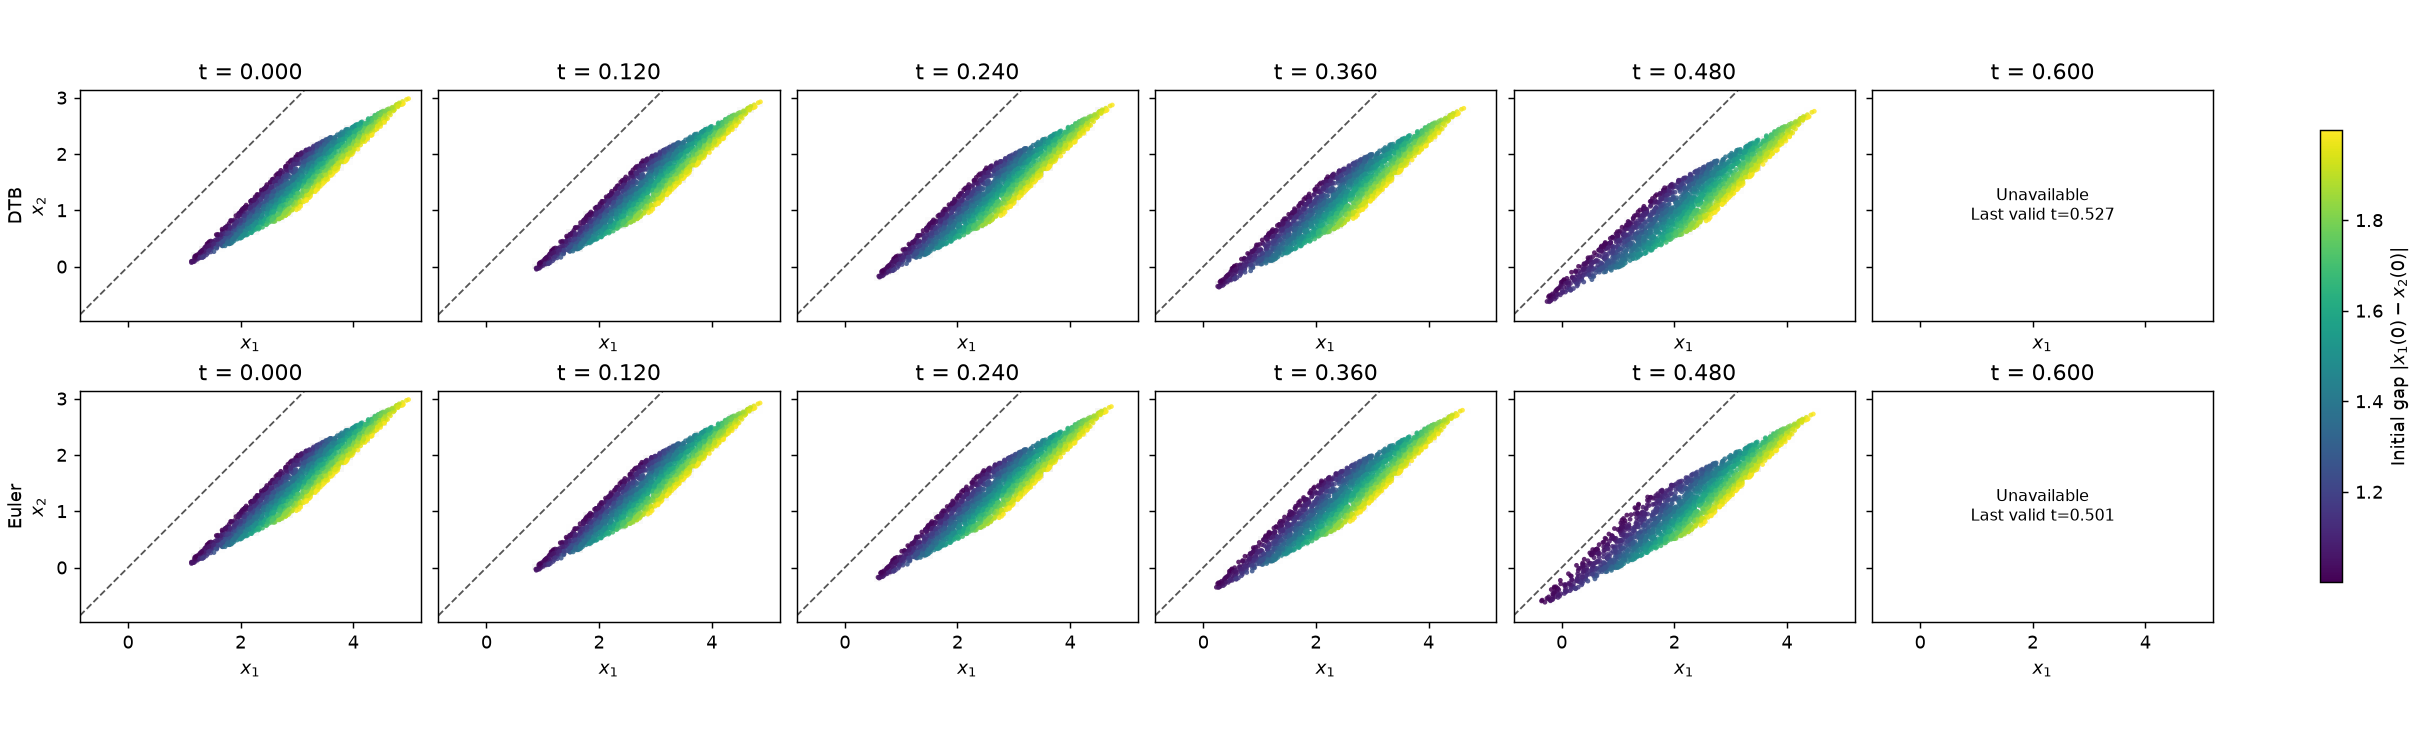

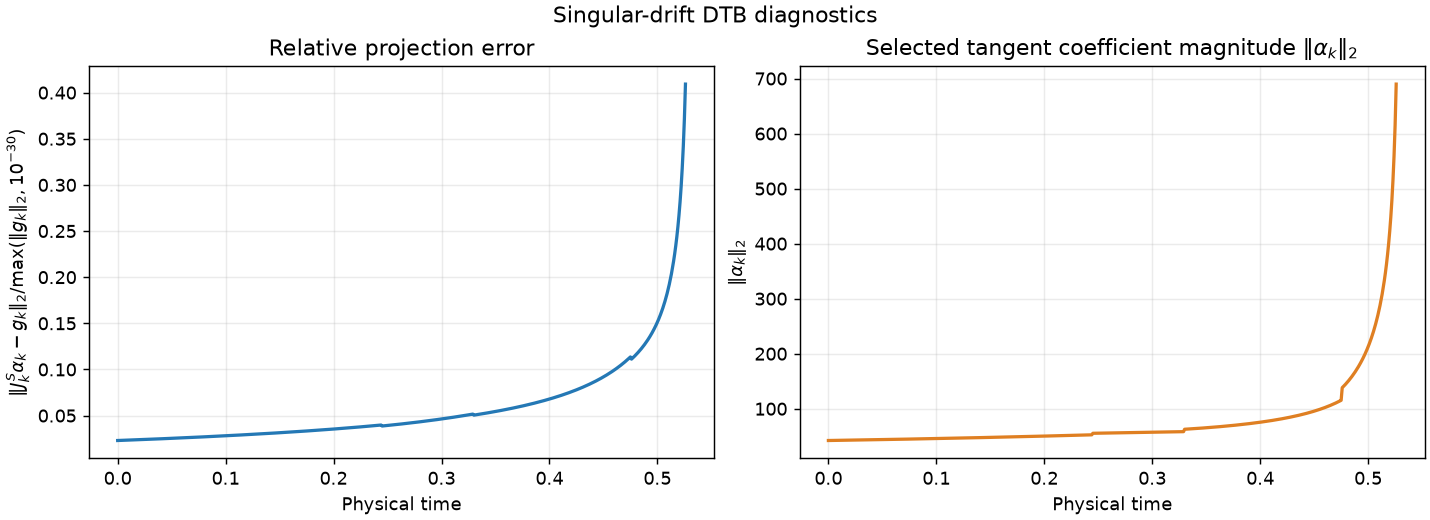

In [5]:
def plot_aligned_snapshots(dtb=None, euler=None):
    runs = [(name, run) for name, run in (('DTB', dtb), ('Euler', euler)) if run is not None]
    if not runs:
        return None
    shown_times = np.unique(np.concatenate([run['requested_snapshot_times'] for _, run in runs]))
    initial_points = runs[0][1]['snapshot_labels'].detach().cpu().numpy()
    if any(not np.array_equal(initial_points, run['snapshot_labels'].detach().cpu().numpy())
           for _, run in runs):
        raise ValueError('Aligned comparisons require identical initial snapshot particles.')
    all_points = np.concatenate([run['snapshots'].numpy().reshape(-1, 2) for _, run in runs])
    low, high = all_points.min(axis=0), all_points.max(axis=0)
    padding = np.maximum(0.1, 0.04*(high-low))
    x_edges = np.linspace(low[0]-padding[0], high[0]+padding[0], 41)
    y_edges = np.linspace(low[1]-padding[1], high[1]+padding[1], 41)
    bin_area = np.diff(x_edges)[:, None]*np.diff(y_edges)[None, :]
    densities = {}
    for row, (_, run) in enumerate(runs):
        for column, t in enumerate(shown_times):
            matches = np.flatnonzero(np.isclose(run['snapshot_times'], t, rtol=0, atol=1e-12))
            if len(matches):
                q = run['snapshots'][int(matches[0])].numpy()
                density = np.histogram2d(q[:, 0], q[:, 1], bins=(x_edges, y_edges))[0]/(len(q)*bin_area)
                densities[row, column] = (q, density)
    density_norm = Normalize(vmin=0, vmax=max(d.max() for _, d in densities.values()))
    # Fixed colors identify the SAME particles across both methods and all times.
    initial_gap = np.abs(initial_points[:, 0]-initial_points[:, 1])
    gap_norm = Normalize(vmin=initial_gap.min(), vmax=initial_gap.max())
    fig, axes = plt.subplots(len(runs), len(shown_times),
                             figsize=(3.1*len(shown_times), 2.7*len(runs)+0.3),
                             sharex=True, sharey=True, squeeze=False, layout='compressed')
    for row, (name, run) in enumerate(runs):
        for column, t in enumerate(shown_times):
            ax = axes[row, column]
            ax.set(xlim=(x_edges[0], x_edges[-1]), ylim=(y_edges[0], y_edges[-1]),
                   title=f't = {t:.3f}', xlabel='$x_1$')
            ax.set_aspect('equal', adjustable='box')
            if column == 0:
                ax.set_ylabel(f'{name}\n$x_2$')
            if (row, column) not in densities:
                ax.text(.5, .5, f"Unavailable\nLast valid t={run['snapshot_times'][-1]:.3f}",
                        ha='center', va='center', transform=ax.transAxes, fontsize=9)
                continue
            points, density = densities[row, column]
            ax.pcolormesh(x_edges, y_edges, density.T, cmap='Greys', alpha=.22,
                          norm=density_norm, shading='auto', rasterized=True)
            ax.scatter(points[:, 0], points[:, 1], c=initial_gap, cmap='viridis', norm=gap_norm,
                       s=7, alpha=.85, linewidths=0, rasterized=True)
            diagonal = [max(x_edges[0], y_edges[0]), min(x_edges[-1], y_edges[-1])]
            ax.plot(diagonal, diagonal, '--', color='#555555', lw=1)
    fig.colorbar(plt.cm.ScalarMappable(norm=gap_norm, cmap='viridis'),
                 ax=axes.ravel().tolist(), label=r'Initial gap $|x_1(0)-x_2(0)|$', shrink=.85)
    return fig


# Run plots after whichever simulation blocks are enabled.
active_dtb = dtb_result if RUN_DTB else None
active_euler = euler_result if RUN_EULER else None
fig_snapshots = plot_aligned_snapshots(active_dtb, active_euler)
if fig_snapshots is not None:
    plt.show()
else:
    print('No enabled simulation results to plot.')

fig_diagnostics = None
if active_dtb is not None and len(active_dtb['alpha']):
    fig_diagnostics = plot_tangent_diagnostics(
        active_dtb['diagnostic_times'], active_dtb['projection_error'],
        active_dtb['alpha'].norm(dim=1).numpy())
    fig_diagnostics.suptitle('Singular-drift DTB diagnostics')
    plt.show()
